# BrushCue Example: Oval

<a href="https://colab.research.google.com/github/ditotechnologies/brushcue/blob/main/examples/oval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

You can use this tool online at https://www.brushcue.com/tools/oval

In [ ]:
!pip install brushcue

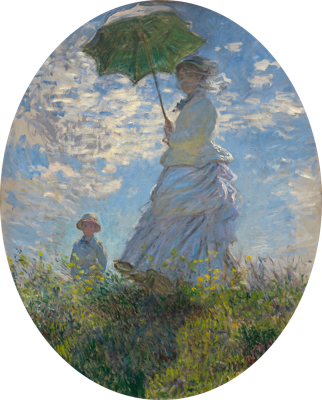

In [1]:
import brushcue
from PIL import Image
import io

input_image_1 = brushcue.composition_monet_women_with_parasol() # insert your own image here
string_constant_2 = brushcue.string_constant("    // Texture size\n    let dims = textureDimensions(input_texture);\n    let width  = f32(dims.x);\n    let height = f32(dims.y);\n\n    // Center\n    let center = vec2<f32>(width * 0.5, height * 0.5);\n\n    // Pixel center\n    let uv = vec2<f32>(\n        f32(position.x) + 0.5,\n        f32(position.y) + 0.5\n    );\n\n    let diff = uv - center;\n\n    // Ellipse radii\n    let a = width  * 0.5;\n    let b = height * 0.5;\n\n    // Normalized ellipse distance\n    let d =\n        (diff.x * diff.x) / (a * a) +\n        (diff.y * diff.y) / (b * b);\n\n    // Edge softness (pixels)\n    let feather_px = 1.5;\n    let max_r = max(a, b);\n    let feather = feather_px / max_r;\n\n    // Alpha mask (1 = inside, 0 = outside)\n    let mask = 1.0 - smoothstep(\n        1.0 - feather,\n        1.0 + feather,\n        d\n    );\n\n    // Linear blend\n    let rgba = mix(background_color, input.rgba, mask);\n\n    return rgba;")
string_constant_3 = brushcue.string_constant("// Oval frame shader - creates an elliptical border")
composition_color_profile_4 = brushcue.composition_color_profile(input_image_1)
bool_constant_5 = brushcue.bool_constant(True)
dictionary_create_6 = brushcue.dictionary_create()
string_constant_7 = brushcue.string_constant("background_color")
background_color_8 = brushcue.r_g_b_a_color_constant(0, 0, 0, 0)
background_color_dictionary_9 = brushcue.r_g_b_a_color_add_to_dictionary(dictionary_create_6, string_constant_7, background_color_8)
oval_shader_10 = brushcue.composition_custom_transformer_shader(input_image_1, string_constant_2, string_constant_3, composition_color_profile_4, composition_color_profile_4, background_color_dictionary_9, bool_constant_5)

ctx = brushcue.Context()
result = oval_shader_10.execute(ctx)
composition = result.as_composition()
data_bytes = composition.to_image_bytes(ctx)
img = Image.open(io.BytesIO(data_bytes))
img.thumbnail((400, 400)) # remove this line for full resolution
img
